In [ ]:
import numpy as np

data = np.load("/content/sample_data/mnist.npz")

print(data.files)

['x_test', 'x_train', 'y_train', 'y_test']


In [ ]:
X_train = data["x_train"]
y_train = data["y_train"]
X_test = data["x_test"]
y_test = data["y_test"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("First label:", y_train[0])


X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
First label: 5


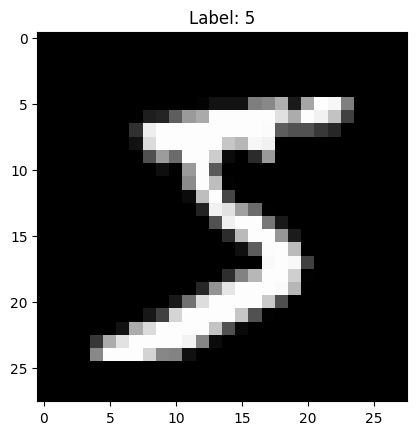

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.show()

In [ ]:
#flattening
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

print(X_train.shape)
print(X_test.shape)



(60000, 784)
(10000, 784)


In [ ]:
#normalizing
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

In [ ]:
print(X_train.min())
print(X_train.max())

0.0
1.0


In [ ]:
#one hot encoding for labels of y
def one_hot(y, num_classes=10):
    result = np.zeros((len(y), num_classes))
    result[np.arange(len(y)), y] = 1
    return result

In [ ]:
y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)

In [ ]:
print(y_train[0])
print(y_train_oh[0])

5
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [ ]:
#network
input_size = 784
hidden_size = 128
output_size = 10

W1 = np.random.randn(input_size, hidden_size)*0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size)*0.01
b2 = np.zeros((1, output_size))


print("W1:", W1.shape)
print("b1:", b1.shape)

print("W2:", W2.shape)
print("b2:", b2.shape),

W1: (784, 128)
b1: (1, 128)
W2: (128, 10)
b2: (1, 10)


(None,)

In [ ]:
#input image
x = X_train[0:1]
print("Input shape:", x.shape)

Input shape: (1, 784)


In [ ]:
#first layer
z1 = x @ W1 + b1
print("z1 shape:", z1.shape)

z1 shape: (1, 128)


In [ ]:
#relu activation
def relu(z):
    return np.maximum(0, z)

a1 = relu(z1)

print("a1 shape:", a1.shape)
print("First 10 ReLU values:", a1[0][:10])

a1 shape: (1, 128)
First 10 ReLU values: [0.06192063 0.07827637 0.         0.         0.         0.10632338
 0.         0.07749028 0.         0.        ]


In [ ]:
#second layer
z2 = a1 @ W2 + b2

print("z2 shape:", z2.shape)
print("Raw output scores:", z2)

z2 shape: (1, 10)
Raw output scores: [[-0.00470719 -0.00394512  0.0005775  -0.00095302 -0.01522475 -0.00231478
   0.00855845 -0.01210396 -0.00624411 -0.00865912]]


In [ ]:
#applying softmax for probabilities
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


a2 = softmax(z2)

print("Probabilities:", a2)
print("Sum of probabilities:", np.sum(a2))
print("Predicted digit:", np.argmax(a2))
print("Actual digit:", y_train[0])

Probabilities: [[0.09997741 0.10005363 0.10050716 0.10035345 0.0989314  0.10021688
  0.10131251 0.09924063 0.09982387 0.09958308]]
Sum of probabilities: 1.0
Predicted digit: 6
Actual digit: 5


In [ ]:
#cross entropy loss
def cross_entropy_loss(y_pred, y_true):
    eps = 1e-9
    loss = -np.sum(y_true * np.log(y_pred + eps))
    return loss

In [ ]:
#loss
y_true = y_train_oh[0:1]
loss = cross_entropy_loss(a2, y_true)

print("Prediction probabilities:", a2)
print("True one-hot label:", y_true)
print("Loss:", loss)

Prediction probabilities: [[0.09997741 0.10005363 0.10050716 0.10035345 0.0989314  0.10021688
  0.10131251 0.09924063 0.09982387 0.09958308]]
True one-hot label: [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]
Loss: 2.3004186213650053


In [ ]:
#backpropagation
dZ2 = a2 - y_true

dW2 = a1.T @ dZ2
db2 = np.sum(dZ2, axis=0, keepdims=True)

dA1 = dZ2 @ W2.T

dZ1 = dA1 * (z1 > 0)

dW1 = x.T @ dZ1
db1 = np.sum(dZ1, axis=0, keepdims=True)

lr = 0.01

W2 -= lr * dW2
b2 -= lr * db2

W1 -= lr * dW1
b1 -= lr * db1

In [ ]:
#loss loop over 100 images using stochastic gradient descent
lr = 0.01
for i in range(100):
  x = X_train[i:i+1]
  y_true = y_train_oh[i:i+1]
  z1 = x @ W1 + b1
  a1 = relu(z1)
  z2 = a1 @ W2 + b2
  a2 = softmax(z2)
  loss = cross_entropy_loss(a2, y_true)
  dZ2 = a2 - y_true
  dW2 = a1.T @ dZ2
  db2 = np.sum(dZ2, axis=0, keepdims=True)
  dA1 = dZ2 @ W2.T
  dZ1 = dA1 * (z1 > 0)
  dW1 = x.T @ dZ1
  db1 = np.sum(dZ1, axis=0, keepdims=True)
  W2 -= lr * dW2
  b2 -= lr * db2
  W1 -= lr * dW1
  b1 -= lr * db1
  if i % 10 == 0:
    print("Step:", i, "Loss:", loss)


Step: 0 Loss: 2.371031534490367
Step: 10 Loss: 2.246213943024905
Step: 20 Loss: 2.275913410074353
Step: 30 Loss: 2.2289605043748173
Step: 40 Loss: 2.223873611275217
Step: 50 Loss: 2.199474520776471
Step: 60 Loss: 2.2787574083332403
Step: 70 Loss: 2.232094887849179
Step: 80 Loss: 2.314327828424195
Step: 90 Loss: 2.1801524600493862


In [ ]:
def predict(x):
  z1 = x @ W1 + b1
  a1 = relu(z1)
  z2 = a1 @ W2 + b2
  a2 = softmax(z2)
  return np.argmax(a2)

In [ ]:
pred = predict(X_test[0:1])
print("Prediction:", pred)
print("Actual:", y_test[0])

Prediction: 0
Actual: 7


In [ ]:
#Building the MLP and updating weights using Mini-Batch Gradient Descent
np.random.seed(42)
input_size = 784
hidden_size = 128
output_size = 10
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

def relu(z):
    return np.maximum(0, z)

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    eps = 1e-9
    return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))

def predict(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = softmax(z2)

    return np.argmax(a2, axis=1)

def accuracy(X, y):
    preds = predict(X)
    return np.mean(preds == y)

epochs = 5
batch_size = 64
lr = 0.1

for epoch in range(epochs):

    indices = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train_oh[indices]

    total_loss = 0
    num_batches = 0

    for i in range(0, X_train.shape[0], batch_size):
        x = X_train_shuffled[i:i + batch_size]
        y_true = y_train_shuffled[i:i + batch_size]

        m = x.shape[0]

        # Forward pass
        z1 = x @ W1 + b1
        a1 = relu(z1)

        z2 = a1 @ W2 + b2
        a2 = softmax(z2)

        # Loss
        loss = cross_entropy_loss(a2, y_true)
        total_loss += loss
        num_batches += 1

        # Backpropagation
        dZ2 = a2 - y_true

        dW2 = a1.T @ dZ2 / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * (z1 > 0)

        dW1 = x.T @ dZ1 / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # Update weights
        W2 -= lr * dW2
        b2 -= lr * db2

        W1 -= lr * dW1
        b1 -= lr * db1

    avg_loss = total_loss / num_batches

    train_acc = accuracy(X_train[:5000], y_train[:5000])
    test_acc = accuracy(X_test, y_test)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {avg_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )


print("\nSample predictions:")

for i in range(10):
    x = X_test[i:i + 1]
    pred = predict(x)[0]
    actual = y_test[i]

    print(f"Image {i}: Predicted = {pred}, Actual = {actual}")

Epoch 1/5 | Loss: 0.5473 | Train Acc: 0.9258 | Test Acc: 0.9170
Epoch 2/5 | Loss: 0.2425 | Train Acc: 0.9524 | Test Acc: 0.9414
Epoch 3/5 | Loss: 0.1840 | Train Acc: 0.9632 | Test Acc: 0.9528
Epoch 4/5 | Loss: 0.1478 | Train Acc: 0.9692 | Test Acc: 0.9597
Epoch 5/5 | Loss: 0.1241 | Train Acc: 0.9764 | Test Acc: 0.9640

Sample predictions:
Image 0: Predicted = 7, Actual = 7
Image 1: Predicted = 2, Actual = 2
Image 2: Predicted = 1, Actual = 1
Image 3: Predicted = 0, Actual = 0
Image 4: Predicted = 4, Actual = 4
Image 5: Predicted = 1, Actual = 1
Image 6: Predicted = 4, Actual = 4
Image 7: Predicted = 9, Actual = 9
Image 8: Predicted = 6, Actual = 5
Image 9: Predicted = 9, Actual = 9
